# Task 3.3 – Clustering

K-means clustering **from scratch** on the seeds dataset to group seeds into different types. We find the optimal number of clusters, print and explain cluster centers, and visualize results with PCA. **Target label (Class) is used only after clustering** for visualization and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

/Users/sooryas/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/sooryas/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
# Load data: X = features only; y_true = Class (used only after clustering)
df = pd.read_csv("seeds_data.csv")
feature_cols = [f"Feature_{i}" for i in range(1, 8)]
X = df[feature_cols].values.astype(np.float64)
y_true = df["Class"].values
# Standardize for K-means
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_std[X_std == 0] = 1.0
X_scaled = (X - X_mean) / X_std
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}. Class stored for later use only.")

Samples: 210, Features: 7. Class stored for later use only.


In [ ]:
# K-means from scratch (NumPy only)
def kmeans(X, K, max_iters=100, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    n = X.shape[0]
    # Initialize centers: K random distinct data points
    idx = np.random.choice(n, size=K, replace=False)
    centers = X[idx].copy()
    labels = np.zeros(n, dtype=int)
    for _ in range(max_iters):
        # Assign each point to nearest center (Euclidean)
        for i in range(n):
            dists = np.linalg.norm(X[i] - centers, axis=1)
            labels[i] = np.argmin(dists)
        # Update centers as mean of assigned points
        new_centers = np.zeros_like(centers)
        for k in range(K):
            mask = labels == k
            if mask.sum() > 0:
                new_centers[k] = X[mask].mean(axis=0)
            else:
                new_centers[k] = centers[k]
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
    inertia = sum(np.sum((X[labels == k] - centers[k]) ** 2) for k in range(K))
    return labels, centers, inertia

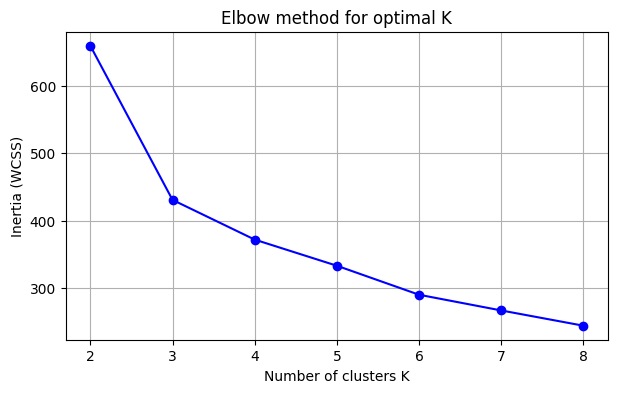

Chosen K = 3 (elbow).


In [ ]:
# Find optimal K: elbow method (multiple inits per K, keep best inertia)
K_range = range(2, 9)
n_inits = 5
inertias = []
for K in K_range:
    best_inertia = np.inf
    for _ in range(n_inits):
        _, _, inertia = kmeans(X_scaled, K, random_state=None)
        best_inertia = min(best_inertia, inertia)
    inertias.append(best_inertia)
plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, "bo-")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow method for optimal K")
plt.xticks(K_range)
plt.grid(True)
plt.show()
# Choose K at the elbow (e.g. 3 for seeds)
optimal_K = 3
print(f"Chosen K = {optimal_K} (elbow).")

In [ ]:
# Fit final K-means with optimal K (best of several inits)
best_inertia = np.inf
for _ in range(10):
    labels_final, centers_scaled, inertia = kmeans(X_scaled, optimal_K, random_state=None)
    if inertia < best_inertia:
        best_inertia = inertia
        cluster_labels = labels_final.copy()
        centers_final_scaled = centers_scaled.copy()
# Centers in original scale for interpretation
centers_original = centers_final_scaled * X_std + X_mean
print("Cluster centers (original feature scale):")
print(pd.DataFrame(centers_original, index=[f"Cluster {k}" for k in range(optimal_K)], columns=feature_cols))

Cluster centers (original feature scale):
           Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
Cluster 0  14.437887  14.337746   0.881597   5.514577   3.259225   2.707341   
Cluster 1  18.495373  16.203433   0.884210   6.175687   3.697537   3.632373   
Cluster 2  11.856944  13.247778   0.848253   5.231750   2.849542   4.742389   

           Feature_7  
Cluster 0   5.120803  
Cluster 1   6.041701  
Cluster 2   5.101722  


## Intuitive explanation of cluster centers

Each row is the **mean** of all seeds assigned to that cluster—the "average seed" for that group. So each center is a prototypical profile across the seven features (e.g. size, shape, compactness). Seeds in the same cluster are similar on these measurements; different clusters represent different seed types Dino Tim can separate.

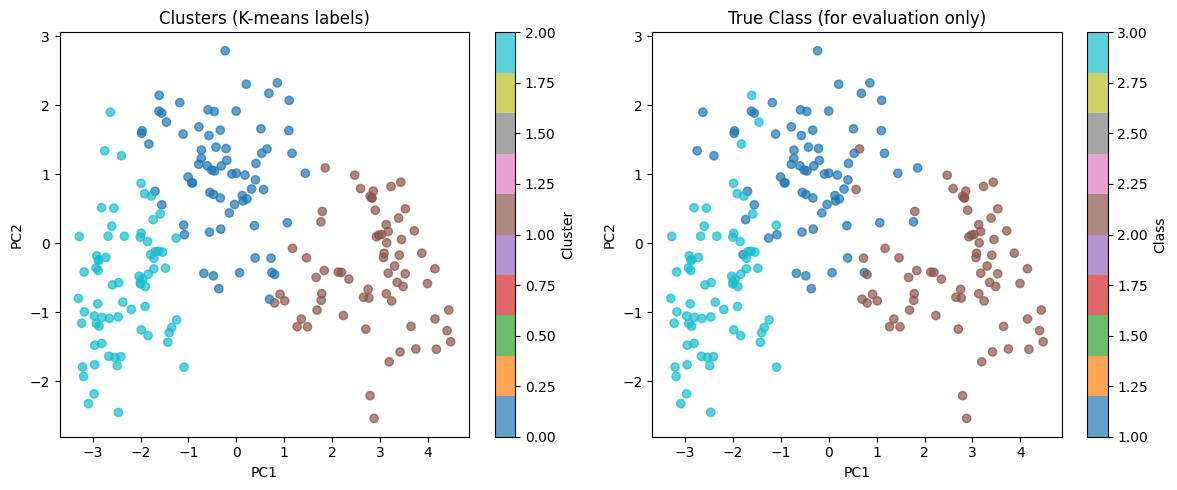

In [ ]:
# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# Plot 1: colored by cluster label (from K-means)
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", alpha=0.7)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("Clusters (K-means labels)")
plt.colorbar(sc1, ax=ax1, label="Cluster")
# Plot 2: colored by true Class (only after clustering—for comparison)
sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap="tab10", alpha=0.7)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title("True Class (for evaluation only)")
plt.colorbar(sc2, ax=ax2, label="Class")
plt.tight_layout()
plt.show()

In [ ]:
# Evaluation using true labels only (after clustering)
ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)
print("Evaluation (true labels used only here):")
print(f"  Adjusted Rand Index: {ari:.4f}")
print(f"  Normalized Mutual Information: {nmi:.4f}")

Evaluation (true labels used only here):
  Adjusted Rand Index: 0.7733
  Normalized Mutual Information: 0.7279


## Summary

K-means was implemented **from scratch** (no sklearn KMeans). Optimal K was chosen via the elbow method. Cluster centers were printed and explained as the average seed profile per group. PCA was used to visualize clusters in 2D; the second plot shows true Class only for comparison. Target labels were used only after clustering for visualization and evaluation (ARI, NMI).